## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

# Parameters
n_groups = 1
n_observations_per_group = 1000
n_dimensions = 5
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

if False:
    # Plot example
    for dim in range(n_dimensions):
        for group_idx in range(n_groups):
            plt.figure()
            for observation in gp_samples[group_idx]:
                plt.plot(time_points, observation[:, dim], label=f"Dim {dim + 1}")
            plt.title(f"Group {group_idx + 1} Observations for Dimension {dim + 1}")
            plt.xlabel("Time")
            plt.ylabel("Value")
            plt.legend()
            plt.show()


100%|██████████| 1000/1000 [00:00<00:00, 1532.52it/s]


In [3]:
n_new_dims = 5
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

In [21]:
from pygrinder import mcar
# Normalize

p_dataset = .3

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), p_dataset)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

#plt.plot(X_ori[1]);

In [22]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 8, 
            epochs = 1000, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (64,32), 
            decoder_sizes = (64,32),
            optimizer = Adam(weight_decay=0.001, lr = 1e-3), #lr = 1e-4
            patience = 100
            )

gpvae.model.backbone.alpha = 1
gpvae.model.backbone.beta = 1e-2
gpvae.model.backbone.gamma = 5 * 1e-5
gpvae.model.backbone.noise_sigma = 1e-3
gpvae.model.backbone.sampling = True
gpvae.model.backbone.use_mean = True
gpvae.model.backbone.noise_std = 1e-2
gpvae.model.backbone.detach = True
gpvae.model.backbone.compensate = False


gpvae.model.backbone.p = 0.5
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train)  # train the model on the dataset

2025-02-24 11:56:56 [INFO]: No given device, using default device: cpu
2025-02-24 11:56:56 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-24 11:56:56 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 6,133


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=8, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=8, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


2025-02-24 11:56:56 [INFO]: Epoch 001 - training loss: 552.1838
2025-02-24 11:56:56 [INFO]: Epoch 002 - training loss: 525.4338
2025-02-24 11:56:57 [INFO]: Epoch 003 - training loss: 437.3776
2025-02-24 11:56:57 [INFO]: Epoch 004 - training loss: 259.8253
2025-02-24 11:56:57 [INFO]: Epoch 005 - training loss: 200.1567
2025-02-24 11:56:58 [INFO]: Epoch 006 - training loss: 170.2050
2025-02-24 11:56:58 [INFO]: Epoch 007 - training loss: 154.5797
2025-02-24 11:56:58 [INFO]: Epoch 008 - training loss: 142.5618
2025-02-24 11:56:58 [INFO]: Epoch 009 - training loss: 132.4785
2025-02-24 11:56:59 [INFO]: Epoch 010 - training loss: 120.1827
2025-02-24 11:56:59 [INFO]: Epoch 011 - training loss: 102.9092
2025-02-24 11:57:00 [INFO]: Epoch 012 - training loss: 84.6108
2025-02-24 11:57:00 [INFO]: Epoch 013 - training loss: 72.7256
2025-02-24 11:57:01 [INFO]: Epoch 014 - training loss: 66.7751
2025-02-24 11:57:01 [INFO]: Epoch 015 - training loss: 62.8312
2025-02-24 11:57:02 [INFO]: Epoch 016 - trai

Plotting latent series and reconstruction...


2025-02-24 11:57:23 [INFO]: Epoch 073 - training loss: 21.3249
2025-02-24 11:57:24 [INFO]: Epoch 074 - training loss: 21.1470
2025-02-24 11:57:24 [INFO]: Epoch 075 - training loss: 21.1030
2025-02-24 11:57:24 [INFO]: Epoch 076 - training loss: 20.8868
2025-02-24 11:57:25 [INFO]: Epoch 077 - training loss: 20.8783
2025-02-24 11:57:25 [INFO]: Epoch 078 - training loss: 20.9020
2025-02-24 11:57:26 [INFO]: Epoch 079 - training loss: 20.6647
2025-02-24 11:57:26 [INFO]: Epoch 080 - training loss: 20.6448
2025-02-24 11:57:26 [INFO]: Epoch 081 - training loss: 20.5319
2025-02-24 11:57:27 [INFO]: Epoch 082 - training loss: 20.4956
2025-02-24 11:57:27 [INFO]: Epoch 083 - training loss: 20.4681
2025-02-24 11:57:27 [INFO]: Epoch 084 - training loss: 20.1760
2025-02-24 11:57:28 [INFO]: Epoch 085 - training loss: 20.2099
2025-02-24 11:57:28 [INFO]: Epoch 086 - training loss: 20.0490
2025-02-24 11:57:29 [INFO]: Epoch 087 - training loss: 19.7944
2025-02-24 11:57:29 [INFO]: Epoch 088 - training loss: 

Plotting latent series and reconstruction...


2025-02-24 11:57:51 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-02-24 11:57:51 [INFO]: Finished training. The best model is from epoch#144.


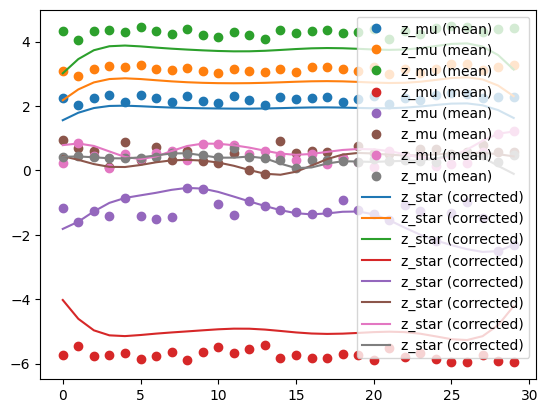

(-3.0, 3.0)

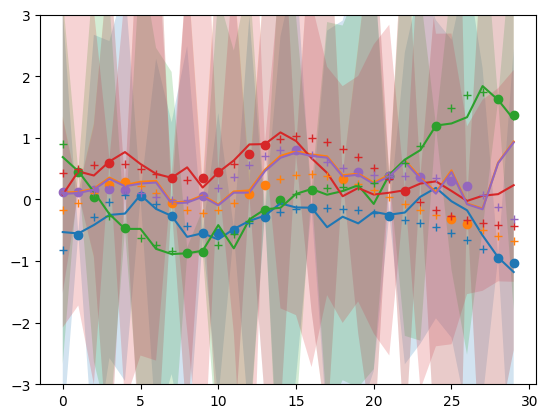

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_with_given_kernel_params(X, kernel_params, gpvae, n_samples=100):
    """
    Reconstructs data using GP-VAE with given kernel parameters, sampling multiple times from the latent distribution.

    Parameters:
    - X: Input data
    - kernel_params: List of kernel parameters
    - gpvae: Trained GP-VAE model
    - n_samples: Number of samples to draw from the latent Gaussian

    Returns:
    - x_input: The original input with NaNs for missing values
    - x_recon_mean: Mean reconstruction across samples
    - x_recon_min: Minimum reconstructed values across samples
    - x_recon_max: Maximum reconstructed values across samples
    """

    # Convert input to tensor
    x_input = torch.tensor(X).float()

    # Encode to obtain latent parameters (mean & variance)
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    # Plot the original latent mean
    plt.plot(z_mu[0].detach(), 'o', label="z_mu (mean)")
    plt.gca().set_prop_cycle(None)

    # Update kernel_params to match batch size and latent dimensions
    kernel_params = torch.tensor(kernel_params).reshape(1, 1, 4).repeat(z_mu.shape[0], z_mu.shape[2], 1)

    # Apply GP correction to latent space
    z_star, z_star_var = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params, return_variance=True)

    z_star_var = z_star_var.clamp(min=0.)
   
    # Plot corrected latent mean
    plt.plot(z_star[0].detach(), label="z_star (corrected)")
    plt.legend()
    plt.show()

    # Sample from Gaussian: z ~ N(z_star, z_star_var)
    z_samples = torch.randn((n_samples,) + z_star.shape) * torch.sqrt(z_star_var) + z_star

    # Decode each sampled latent representation
    x_recon_samples = gpvae.model.backbone.decode(z_samples).mean  # Shape: (n_samples, batch, seq, features)

    # Compute mean, min, and max across samples
    x_recon_mean = x_recon_samples.mean(dim=0)  # Average over n_samples
    x_recon_min = x_recon_samples.min(dim=0).values  # Minimum over n_samples
    x_recon_max = x_recon_samples.max(dim=0).values  # Maximum over n_samples

    # Mask missing values in x_input with NaNs
    x_input[x_input == 0] = torch.nan

    return x_input, x_recon_mean, x_recon_min, x_recon_max

# Example usage
X[X!=X] = 0.
x_input, x_recon_mean, x_recon_min, x_recon_max = reconstruct_with_given_kernel_params(
    X[:10], [-1,0,-4,-2], gpvae
)


plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None);
plt.plot(x_recon_mean[0].detach());
plt.gca().set_prop_cycle(None);
for i in range(x_recon_mean.shape[2]):
    plt.fill_between(np.arange(30),
                    x_recon_min[0,:,i].detach(),
                    x_recon_max[0,:,i].detach(),
                    alpha = .2)
plt.plot(X_normalized[0],'+')
plt.ylim([-3,3])

In [44]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE_posterior_concistency
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae_pc = GP_VAE_posterior_concistency(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 10, 
            epochs = 200, 
            batch_size = 64,
            beta = 1., 
            K = 5,  
            encoder_sizes = (128,64,32), 
            decoder_sizes = (128,32),
            optimizer = Adam(weight_decay=0.001) #lr = 1e-4
            )

gpvae_pc.model.backbone.alpha = 1e-1
gpvae_pc.model.backbone.beta = 1e-2
gpvae_pc.model.backbone.gamma = 5 * 1e-5
gpvae_pc.model.backbone.noise_sigma = 1e-3
gpvae_pc.model.backbone.sampling = False
gpvae_pc.model.backbone.use_mean = True
gpvae_pc.model.backbone.p = 0.3
gpvae_pc.model.backbone.detach = True


# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae_pc.model.backbone.device = 'cpu'
gpvae_pc.fit(dataset_train, dataset_val)  # train the model on the dataset

2025-02-20 16:01:49 [INFO]: No given device, using default device: cpu
2025-02-20 16:01:49 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-02-20 16:01:49 [INFO]: GP_VAE_posterior_concistency initialized with the given hyperparameters, the number of trainable parameters: 18,105


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=32, out_features=10, bias=True)
  (logvar_layer): Linear(in_features=32, out_features=10, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=5, bias=True)
  )
)


2025-02-20 16:01:53 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2025-02-20 16:01:53 [INFO]: Finished training. The best model is from epoch#-1.


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

In [288]:
gpvae.fit_kernel(dataset_train, dataset_val)  # train the model on the dataset

fitting kernel


Epoch 1/20: 11it [00:01,  7.28it/s]


Epoch 1/20: Average Loss = 0.189703


Epoch 2/20: 11it [00:01,  7.45it/s]


Epoch 2/20: Average Loss = 0.179578


...

Epoch 18/20: Average Loss = 0.154388


Epoch 19/20: 11it [00:01,  7.25it/s]


Epoch 19/20: Average Loss = 0.151946


Epoch 20/20: 11it [00:01,  6.94it/s]

Epoch 20/20: Average Loss = 0.153799


In [14]:
log_probs = compute_latent_log_probability(gpvae, X_ori, X)

NameError: name 'compute_latent_log_probability' is not defined

torch.Size([30, 6])
torch.Size([1000, 30, 6]) torch.Size([1000, 30, 6]) torch.Size([1000, 30, 6])


IndexError: index 6 is out of bounds for dimension 2 with size 6

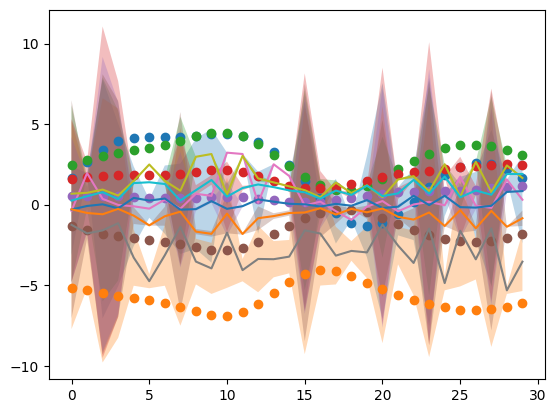

In [284]:
from benchmarking import compute_latent_log_probability
X[X!=X] = 0
compute_latent_log_probability(gpvae, X_ori, X)

In [225]:
gpvae.fit_kernel(dataset_train)  # train the model on the dataset

fitting kernel


Epoch 1/20: 11it [00:02,  4.38it/s]


Epoch 1/20: Average Loss = 0.272356


Epoch 2/20: 11it [00:02,  4.39it/s]


Epoch 2/20: Average Loss = 0.273649


Epoch 3/20: 11it [00:02,  4.39it/s]


Epoch 3/20: Average Loss = 0.270420


Epoch 4/20: 3it [00:00,  3.96it/s]


KeyboardInterrupt: 

In [709]:
#p_dataset = .3
alpha = 1
beta = 1
gamma = 1e-10
gpvae = torch.load(f'gvpae_p_dataset_{p_dataset}-a_{alpha}_b_{beta}_gamma_{gamma}')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/2774675125.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvae = torch.load(f'gvpae_p_dataset_{p_datas

In [770]:
gpvae.model.backbone.gamma = 1e-5
gpvae.model.backbone.alpha = 1e1

gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2024-12-10 17:04:42 [INFO]: Epoch 001 - training loss: 17.5849, validation loss: 0.1250
2024-12-10 17:04:50 [INFO]: Epoch 002 - training loss: 8.5671, validation loss: 0.1135


plotting


2024-12-10 17:04:58 [INFO]: Epoch 003 - training loss: 7.8250, validation loss: 0.1085
2024-12-10 17:05:06 [INFO]: Epoch 004 - training loss: 7.5778, validation loss: 0.1035
2024-12-10 17:05:13 [INFO]: Epoch 005 - training loss: 7.4117, validation loss: 0.1004
2024-12-10 17:05:21 [INFO]: Epoch 006 - training loss: 7.3101, validation loss: 0.0966
2024-12-10 17:05:28 [INFO]: Epoch 007 - training loss: 7.1979, validation loss: 0.0937
2024-12-10 17:05:35 [INFO]: Epoch 008 - training loss: 7.1248, validation loss: 0.0922
2024-12-10 17:05:42 [INFO]: Epoch 009 - training loss: 7.0624, validation loss: 0.0899
2024-12-10 17:05:49 [INFO]: Epoch 010 - training loss: 6.9653, validation loss: 0.0876
2024-12-10 17:05:56 [INFO]: Epoch 011 - training loss: 6.8829, validation loss: 0.0863
2024-12-10 17:06:03 [INFO]: Epoch 012 - training loss: 6.8098, validation loss: 0.0848


plotting


2024-12-10 17:06:12 [INFO]: Epoch 013 - training loss: 6.7548, validation loss: 0.0841
2024-12-10 17:06:19 [INFO]: Epoch 014 - training loss: 6.6994, validation loss: 0.0839
2024-12-10 17:06:26 [INFO]: Epoch 015 - training loss: 6.6823, validation loss: 0.0850
2024-12-10 17:06:32 [INFO]: Epoch 016 - training loss: 6.6709, validation loss: 0.0842
2024-12-10 17:06:38 [INFO]: Epoch 017 - training loss: 6.6743, validation loss: 0.0831
2024-12-10 17:06:44 [INFO]: Epoch 018 - training loss: 6.6901, validation loss: 0.0837
2024-12-10 17:06:51 [INFO]: Epoch 019 - training loss: 6.7245, validation loss: 0.0834
2024-12-10 17:06:56 [INFO]: Epoch 020 - training loss: 6.7463, validation loss: 0.0835
2024-12-10 17:07:02 [INFO]: Epoch 021 - training loss: 6.6478, validation loss: 0.0842
2024-12-10 17:07:08 [INFO]: Epoch 022 - training loss: 6.5334, validation loss: 0.0846


...

2024-12-10 17:07:16 [INFO]: Epoch 023 - training loss: 6.4253, validation loss: 0.0842
2024-12-10 17:07:22 [INFO]: Epoch 024 - training loss: 6.4058, validation loss: 0.0864
2024-12-10 17:07:29 [INFO]: Epoch 025 - training loss: 6.3883, validation loss: 0.0866
2024-12-10 17:07:36 [INFO]: Epoch 026 - training loss: 6.4149, validation loss: 0.0864
2024-12-10 17:07:45 [INFO]: Epoch 027 - training loss: 6.4422, validation loss: 0.0886
2024-12-10 17:07:52 [INFO]: Epoch 028 - training loss: 6.3668, validation loss: 0.0864
2024-12-10 17:07:57 [INFO]: Epoch 029 - training loss: 6.1779, validation loss: 0.0888
2024-12-10 17:08:05 [INFO]: Epoch 030 - training loss: 6.1805, validation loss: 0.0892
2024-12-10 17:08:11 [INFO]: Epoch 031 - training loss: 6.1648, validation loss: 0.0917
2024-12-10 17:08:17 [INFO]: Epoch 032 - training loss: 6.0616, validation loss: 0.0898


plotting


2024-12-10 17:08:25 [INFO]: Epoch 033 - training loss: 5.8751, validation loss: 0.0914
2024-12-10 17:08:32 [INFO]: Epoch 034 - training loss: 5.9607, validation loss: 0.0992
2024-12-10 17:08:39 [INFO]: Epoch 035 - training loss: 5.7205, validation loss: 0.0922
2024-12-10 17:08:46 [INFO]: Epoch 036 - training loss: 5.6364, validation loss: 0.0931
2024-12-10 17:08:52 [INFO]: Epoch 037 - training loss: 5.6711, validation loss: 0.0947
2024-12-10 17:08:59 [INFO]: Epoch 038 - training loss: 5.7052, validation loss: 0.0964
2024-12-10 17:09:05 [INFO]: Epoch 039 - training loss: 5.6887, validation loss: 0.0961
2024-12-10 17:09:11 [INFO]: Epoch 040 - training loss: 5.7144, validation loss: 0.0982
2024-12-10 17:09:18 [INFO]: Epoch 041 - training loss: 5.6846, validation loss: 0.1001
2024-12-10 17:09:25 [INFO]: Epoch 042 - training loss: 5.7759, validation loss: 0.0981
2024-12-10 17:09:33 [INFO]: Epoch 043 - training loss: 5.7194, validation loss: 0.1045


plotting


2024-12-10 17:09:44 [INFO]: Epoch 044 - training loss: 5.7539, validation loss: 0.1027
2024-12-10 17:09:51 [INFO]: Epoch 045 - training loss: 5.7991, validation loss: 0.1013
2024-12-10 17:09:58 [INFO]: Epoch 046 - training loss: 5.8195, validation loss: 0.1039
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1063492e0>>
Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
2024-12-10 17:10:06 [INFO]: Epoch 047 - training loss: 5.7591, validation loss: 0.1034
2024-12-10 17:10:08 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-12-10 17:10:08 [INFO]: Finished training. The best model is from epoch#17.


In [230]:
X[X!=X] = 0

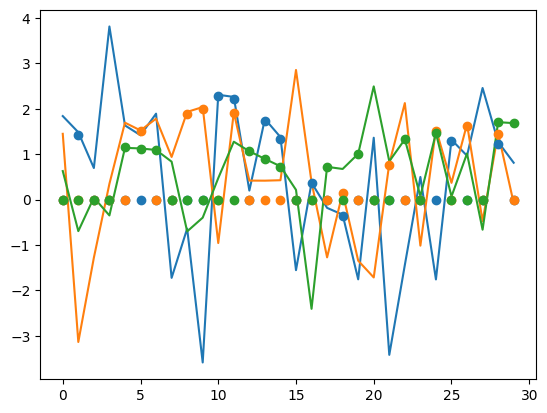

In [294]:
import torch

qz_x = gpvae.model.backbone.encode(torch.tensor(X).float())
z = qz_x.rsample()
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.gca().set_prop_cycle(None)
plt.plot(X[0],'o')
plt.show();

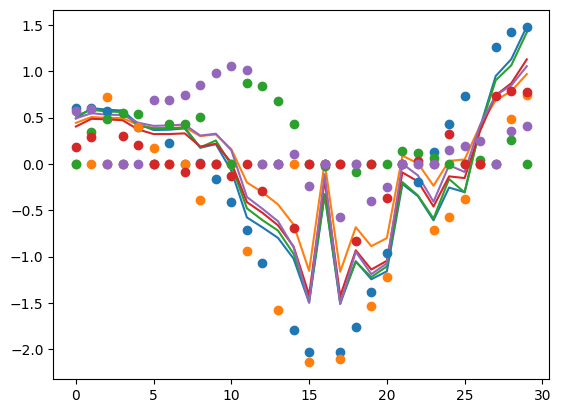

In [183]:
import torch

qz_x = gpvae_pc.model.backbone.encode(torch.tensor(X).float())
z = qz_x.mean
X_recon = gpvae_pc.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.gca().set_prop_cycle(None)
plt.plot(X[0],'o')
plt.show();

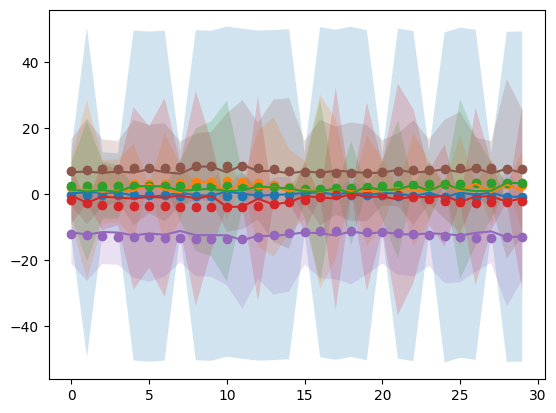

In [304]:
x_input_ori = torch.tensor(X_normalized).float()

qz_x = gpvae.model.backbone.encode(x_input_ori)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

plt.plot(z_mu[0].detach(),'o')

plt.gca().set_prop_cycle(None)

X[X!=X] = 0.
x_input = torch.tensor(X).float()
qz_x = gpvae.model.backbone.encode(x_input)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

mean = z_mu[0].detach()
var = z_var[0].detach()
plt.plot(mean)
for i in range(mean.shape[1]):
    plt.fill_between(np.arange(mean.shape[0]),
                    mean[:,i]-2*var[:,i], 
                    mean[:,i]+2*var[:,i],
                    alpha = 0.2)




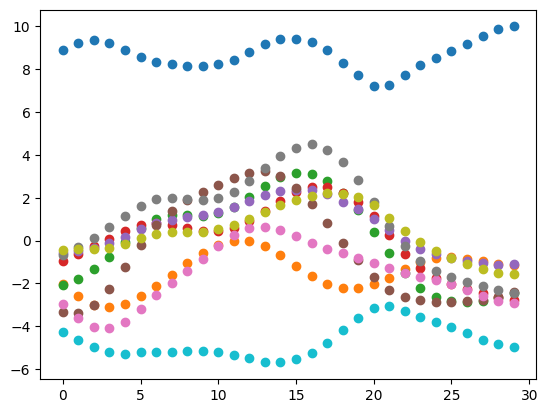

In [262]:
x_input = torch.tensor(X_ori).float()

qz_x = gpvae.model.backbone.encode(x_input)
z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

plt.plot(z_mu[0].detach(),'o')
plt.gca().set_prop_cycle(None)

m, v = gpvae.backbone.encode(dataset_val['X_ori'][:2])


print(m)

KeyError: 'X_normalized'

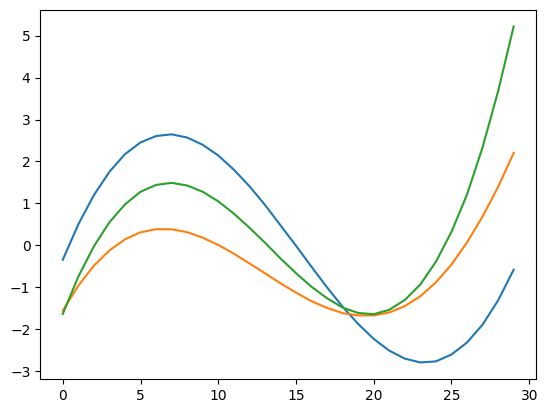

In [303]:
with torch.autograd.set_detect_anomaly(True):
    imputation = gpvae.impute(dataset_val, with_gp = True)

plt.plot(imputation[0]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val['X_ori'][0],'+')
plt.gca().set_prop_cycle(None)
x_observed = dataset_val['X'][0]
x_observed[x_observed==0] = np.nan
plt.plot(x_observed,'o');

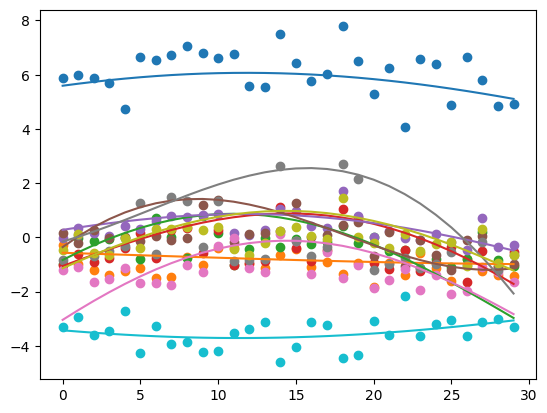

In [244]:
def reconstruct_with_given_kernel_params(X, kernel_params, gpvae):

    x_input = torch.tensor(X).float()
    
    qz_x = gpvae.model.backbone.encode(x_input)
    z_mu, z_var = qz_x.mean.detach(), qz_x.variance.detach()

    plt.plot(z_mu[0].detach(),'o')
    plt.gca().set_prop_cycle(None)

    #print(z_mu[:2].shape, z_var[:2].shape)

    
    # Update kernel_params
    kernel_params = torch.tensor(kernel_params).reshape(1,1,4).repeat(z_mu.shape[0],z_mu.shape[2],1)
    
    # Correct with GP
    z_star, z_star_var = gpvae.gp.correct_with_gp(z_mu, z_var, kernel_params, return_variance = True)

    plt.plot(z_star[0].detach())

    plt.show()

    
    # Reconstruct and compute reconstruction error
    x_recon = gpvae.model.backbone.decode(z_star).mean


    x_input[x_input==0] = torch.nan

    return x_input, x_recon

x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [0.00001,1,.001,0], gpvae)


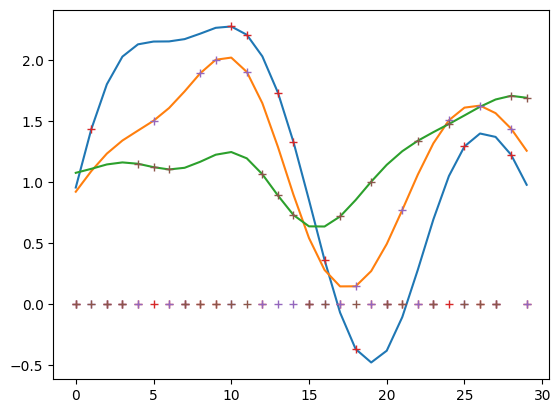

In [302]:
plt.plot(X_normalized[0])
plt.plot(X[0],'+')

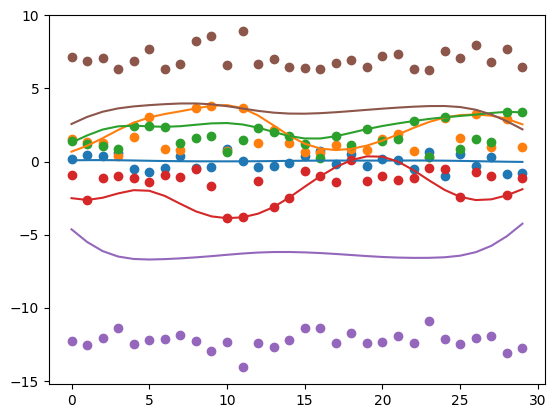

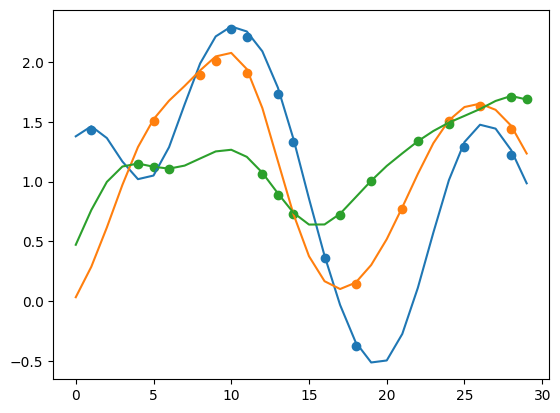

In [305]:
x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [-1,0,-4,-2], gpvae)
plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None)
plt.plot(x_recon[0].detach());

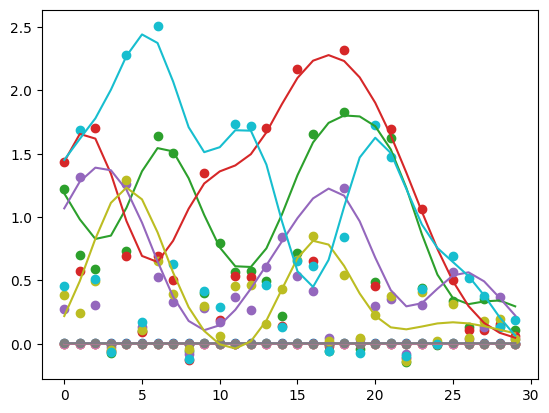

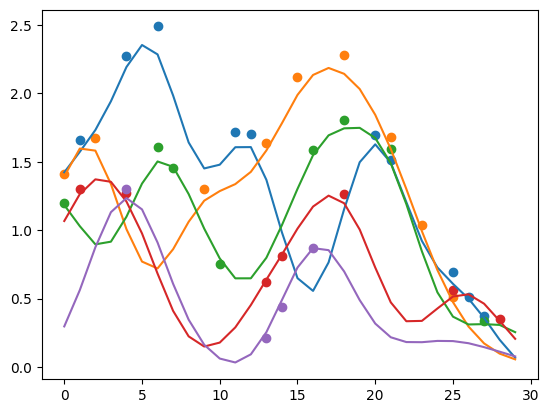

In [65]:
x_input, x_recon = reconstruct_with_given_kernel_params(X[:10], [-1,0,-4,-2], gpvae_pc)
plt.plot(x_input[0].detach(),'o');
plt.gca().set_prop_cycle(None)
plt.plot(x_recon[0].detach());

In [826]:
gpvaee = torch.load('gvpae_p_dataset_0.9-a_1_b_0.1_gamma_1e-10')

/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/1547841420.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpvaee = torch.load('gvpae_p_dataset_0.9-a_1_

In [827]:
from pypots.imputation.gp_ae.gp_model import ProbabilisticGP
gpvae.gp = ProbabilisticGP(gpvae.model.backbone, assemble_data = gpvae._assemble_input_for_training, n_dims = 10, latent_size = 30)
#gpvae.optimizer.lr = 1e-4

In [828]:
gpvae.gp.p = 0.1

In [829]:
gpvae.fit_kernel(dataset_train)  # train the model on the dataset

fitting kernel


Epoch 1/20: 55it [00:33,  1.64it/s]


Epoch 1/20: Average Loss = 0.112911


Epoch 2/20: 55it [00:36,  1.51it/s]


Epoch 2/20: Average Loss = 0.106313


...

Epoch 18/20: Average Loss = 0.069268


Epoch 19/20: 55it [00:36,  1.49it/s]


Epoch 19/20: Average Loss = 0.067511


Epoch 20/20: 55it [00:37,  1.48it/s]

Epoch 20/20: Average Loss = 0.067032


In [830]:
X_torch = torch.tensor(X).float()[:10]
embedding = gpvae.model.backbone.encode(X_torch)
imputed_data = gpvae.gp.infer(embedding, X_torch)

X_recon = gpvae.model.backbone.decode(embedding.mean).mean

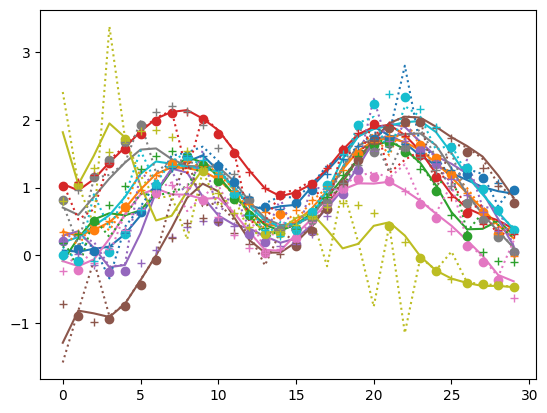

In [835]:
i = 2
X_torch[X_torch==0] = torch.nan
plt.plot(imputed_data[i].detach())
plt.gca().set_prop_cycle(None)
plt.plot(X_recon[i].detach(), ':', label = 'recon')
plt.gca().set_prop_cycle(None)
plt.plot(X_torch[i].detach(), 'o');
plt.gca().set_prop_cycle(None)
plt.plot(X_normalized[i], '+');

In [832]:
gpvae.predict(dataset_val)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/4179161113.py", line 1, in <module>
    gpvae.predict(dataset_val)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 473, in predict
    embedding = self.model.encode(inputs, training=False, n_sampling_times=n_sampling_times)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/core.py", line 124, in encode
    return self.backbone.encode(data)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py", line 144, in encode
    return self.encoder(x, missing_mask)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553

fitting kernel


Epoch 1/50: 157it [00:04, 32.10it/s]


Epoch 1/50: Average Loss = 15212.884736


Epoch 2/50: 157it [00:04, 34.63it/s]


Epoch 2/50: Average Loss = 49.249578


...

Epoch 22/50: 157it [00:04, 33.36it/s]


Epoch 22/50: Average Loss = 1.192580


Epoch 23/50: 47it [00:01, 33.53it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3508, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_84542/4127550510.py", line 1, in <module>
    gpvae.fit_kernel(dataset)  # train the model on the dataset
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 540, in fit_kernel
    self._fit_kernel(training_loader)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/model.py", line 510, in _fit_kernel
    self.gp.fit_kernel(training_loader)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/gp_model.py", line 409, in fit_kernel
    z_star = self.correct_with_gp(z_mu, z_var, kernel_params)
  File "/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/imputation/gp_ae/gp_model.

## RUN THIS

In [ ]:
gpvae.model.backbone.p = 0.1

gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
## Assess reconstruction error
import torch

z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
X_recon = gpvae.model.backbone.decoder(z).mean

error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean()

print(error)

In [ ]:
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.1
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.p = .3
gpvae.model.backbone.sampling = True
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
import gpytorch
import torch
with gpytorch.settings.cholesky_jitter(1e-4):
    with torch.autograd.set_detect_anomaly(True):
        gpvae.fit_kernel(dataset)  # train the model on the dataset


In [ ]:
gpvae.gp.gp_models[0].covar_module.outputscale


In [ ]:
help(gpvae.gp.gp_models[0].covar_module)


In [ ]:
import torch
x = torch.ones((8,48))
gpvae.gp.gp_models[0](x)

In [ ]:
gpvae.gp._fit_kernel

In [ ]:
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GPVAE
from pypots.utils.metrics import calc_mae
gpvae = GPVAE(n_steps=48, n_features=37, latent_size = 12, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import SAITS
from pypots.utils.metrics import calc_mae
gpvae = SAITS(n_steps=48, n_features=37, n_layers=2, d_model=256, n_heads=4, d_k=64, d_v=64, d_ffn=128, dropout=0.1, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/saits_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/saits_physionet2012.pypots")  # reload the serialized model file for following imputation or training